# 02 — Análisis de Características y Decisiones de Preprocesamiento

**Objetivos:**
- Justificar la elección de columnas Q vs QN para cada modelo
- Verificar colinealidad entre features (Spearman)
- Analizar correlación de cada feature con los targets
- Revisar el balance de clases del target de salud mental
- Explorar los scores de features derivadas (IMC, dietary_risk_score, etc.)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load import load_raw
from src.features.engineer import add_all_engineered_features, get_engineered_feature_names
from src.config import (
    REGRESSION_FEATURE_COLS, REGRESSION_TARGET_BMI,
    CLASSIFICATION_FEATURE_COLS, CLASSIFICATION_TARGET_MENTAL_HEALTH,
    REGRESSION_CATEGORICAL_COLS, CLASSIFICATION_CATEGORICAL_COLS,
)
from src.visualization.plots import plot_correlation_matrix

sns.set_theme(style='whitegrid')
%matplotlib inline

df = load_raw('../data/SLV2013_Public_Use.csv')
df = add_all_engineered_features(df)
print(f'Shape: {df.shape}')

Shape: (1915, 110)


## 1. Justificación: ¿Columnas Q o QN?

In [2]:
print("""
DECISIÓN: Evitar mezclar Q y QN del mismo dominio en el mismo modelo.

Cada columna QN es una transformación determinista de su Q correspondiente:
  QN7 = 1 si Q7 >= 4 (fruta ≥2 veces/día), 2 si no.
Incluir ambas introduce colinealidad perfecta o cuasi-perfecta.

MODELO DE REGRESIÓN (predicción de IMC):
  - Usamos columnas Q (originales, ordinales).
  Razón: las escalas ordinales conservan más información numérica que
  una binarización (ej: consumir fruta 1x/día vs 5x/día importa para
  predecir IMC, no solo "cumple o no cumple umbral OMS").

MODELO DE CLASIFICACIÓN (riesgo de salud mental):
  - Usamos columnas QN (dicotomizadas OMS) + Q1/Q2/Q3 (demográficas sin QN equiv.).
  Razón: los QN representan los umbrales epidemiológicos validados por la OMS
  para indicadores de riesgo/protección. La binarización es clínicamente
  significativa aquí (ej: beber alcohol una vez = riesgo, no importa cuántas).

CODIFICACIÓN:
  Q1 (edad), Q2 (sexo), Q3 (grado) - One-Hot Encoding (drop='first')
  porque son categóricas nominales/ordinales sin relación lineal con el target.
  El resto (Q y QN ordinales) - tratadas como numéricas, escaladas con StandardScaler.
""")

# Verificar correlación entre QN7 y Q7 para demostrar colinealidad
corr = df[['Q7', 'QN7']].corr(method='spearman').loc['Q7', 'QN7']
print(f"Correlación Spearman entre Q7 y QN7: {corr:.4f}  ← colinealidad casi perfecta")


DECISIÓN: Evitar mezclar Q y QN del mismo dominio en el mismo modelo.

Cada columna QN es una transformación determinista de su Q correspondiente:
  QN7 = 1 si Q7 >= 4 (fruta ≥2 veces/día), 2 si no.
Incluir ambas introduce colinealidad perfecta o cuasi-perfecta.

MODELO DE REGRESIÓN (predicción de IMC):
  - Usamos columnas Q (originales, ordinales).
  Razón: las escalas ordinales conservan más información numérica que
  una binarización (ej: consumir fruta 1x/día vs 5x/día importa para
  predecir IMC, no solo "cumple o no cumple umbral OMS").

MODELO DE CLASIFICACIÓN (riesgo de salud mental):
  - Usamos columnas QN (dicotomizadas OMS) + Q1/Q2/Q3 (demográficas sin QN equiv.).
  Razón: los QN representan los umbrales epidemiológicos validados por la OMS
  para indicadores de riesgo/protección. La binarización es clínicamente
  significativa aquí (ej: beber alcohol una vez = riesgo, no importa cuántas).

CODIFICACIÓN:
  Q1 (edad), Q2 (sexo), Q3 (grado) - One-Hot Encoding (drop='first')
 

## 2. Correlación entre features de regresión (colinealidad interna)

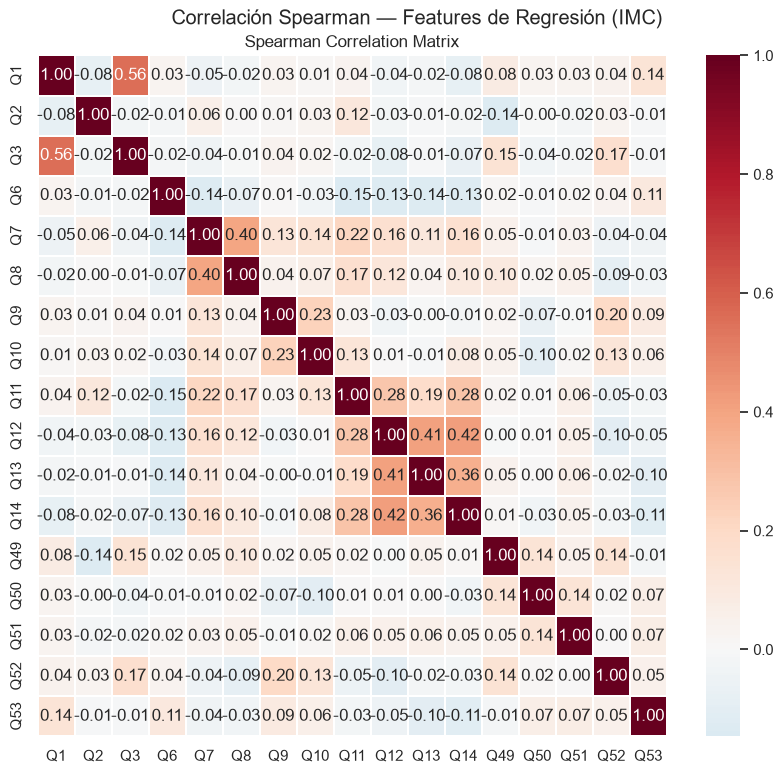


Pares con correlación |r| > 0.4 (posible colinealidad):
  Q1 ↔ Q3: r=0.559
  Q12 ↔ Q14: r=0.417
  Q12 ↔ Q13: r=0.410


In [3]:
fig = plot_correlation_matrix(df, REGRESSION_FEATURE_COLS)
plt.suptitle('Correlación Spearman — Features de Regresión (IMC)', y=1.01)
plt.show()

# Pares con alta correlación (|r| > 0.4)
avail = [c for c in REGRESSION_FEATURE_COLS if c in df.columns]
corr_mat = df[avail].corr(method='spearman').abs()
high_corr = [(i, j, corr_mat.loc[i, j])
             for i in avail for j in avail
             if i < j and corr_mat.loc[i, j] > 0.4]
if high_corr:
    print('\nPares con correlación |r| > 0.4 (posible colinealidad):')
    for i, j, r in sorted(high_corr, key=lambda x: -x[2]):
        print(f'  {i} ↔ {j}: r={r:.3f}')
else:
    print('\nNo se detectó colinealidad alta entre las features de regresión (|r| ≤ 0.4).')

## 3. Correlación de features con el target IMC

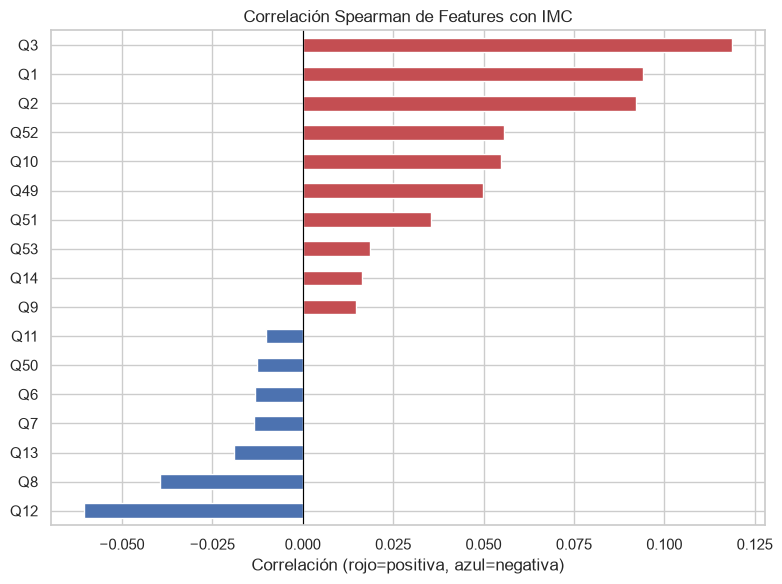


Top 5 features más correlacionadas con IMC:
Q3     0.118804
Q1     0.094033
Q2     0.092193
Q12    0.060602
Q52    0.055553
Name: bmi, dtype: float64


In [4]:
avail_reg = [c for c in REGRESSION_FEATURE_COLS if c in df.columns]
corr_bmi = df[avail_reg + [REGRESSION_TARGET_BMI]].corr(method='spearman')[REGRESSION_TARGET_BMI].drop(REGRESSION_TARGET_BMI).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#C44E52' if x > 0 else '#4C72B0' for x in corr_bmi]
corr_bmi.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación Spearman de Features con IMC')
ax.set_xlabel('Correlación (rojo=positiva, azul=negativa)')
plt.tight_layout()
plt.show()

print('\nTop 5 features más correlacionadas con IMC:')
print(corr_bmi.abs().sort_values(ascending=False).head())

## 4. Correlación de features con el target de salud mental

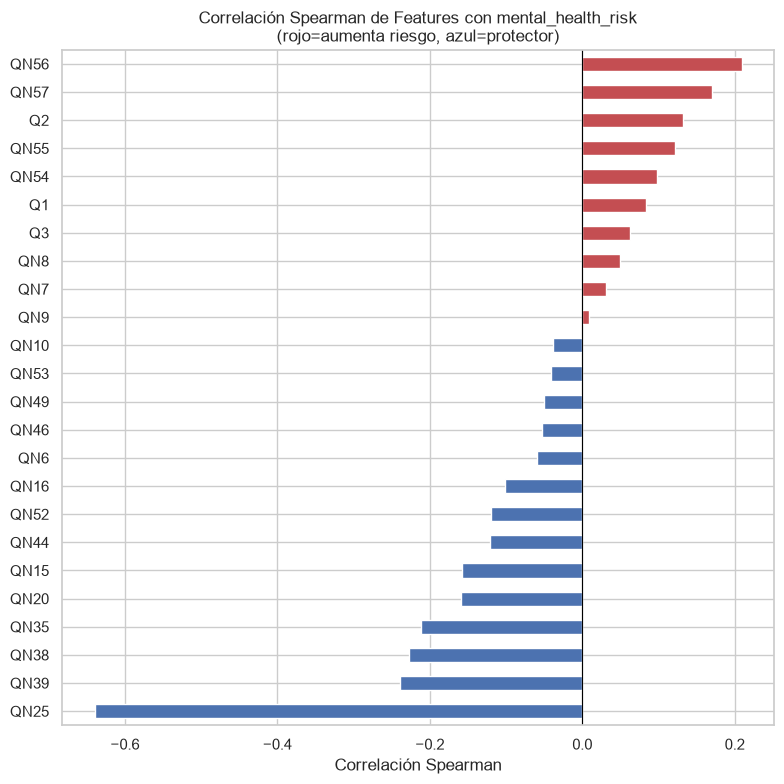


Top 5 features de RIESGO (correlación positiva):
QN56    0.209066
QN57    0.169728
Q2      0.131782
QN55    0.121100
QN54    0.098507
Name: mental_health_risk, dtype: float64

Top 5 features PROTECTORAS (correlación negativa):
QN25   -0.639924
QN39   -0.239278
QN38   -0.227219
QN35   -0.211503
QN20   -0.159033
Name: mental_health_risk, dtype: float64


In [5]:
avail_cls = [c for c in CLASSIFICATION_FEATURE_COLS if c in df.columns]
target = CLASSIFICATION_TARGET_MENTAL_HEALTH

corr_mhr = df[avail_cls + [target]].corr(method='spearman')[target].drop(target).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#C44E52' if x > 0 else '#4C72B0' for x in corr_mhr]
corr_mhr.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación Spearman de Features con mental_health_risk\n(rojo=aumenta riesgo, azul=protector)')
ax.set_xlabel('Correlación Spearman')
plt.tight_layout()
plt.show()

print('\nTop 5 features de RIESGO (correlación positiva):')
print(corr_mhr[corr_mhr > 0].sort_values(ascending=False).head())
print('\nTop 5 features PROTECTORAS (correlación negativa):')
print(corr_mhr[corr_mhr < 0].sort_values().head())

## 5. Balance de clases y desbalance

Distribución: {0: 1675, 1: 240}
Ratio de desbalance: 7.0:1

Estrategia de manejo del desbalance:
  1. class_weight="balanced" en LogisticRegression y RandomForestClassifier
     - ajusta automáticamente los pesos de clase inversamente proporcional
        a su frecuencia.
  2. SMOTE (Synthetic Minority Over-sampling Technique) dentro del pipeline
     de imblearn - genera muestras sintéticas de la clase minoritaria
     SOLO en los folds de entrenamiento (evita data leakage).
  3. Métrica principal: F1-Score clase minoritaria + AUC-ROC
     (no accuracy, que sería engañosamente alta con clases desbalanceadas).


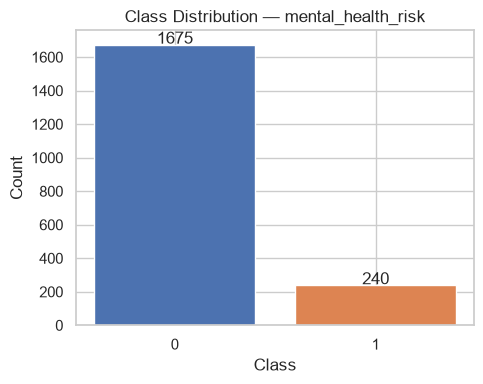

In [6]:
mhr = df[CLASSIFICATION_TARGET_MENTAL_HEALTH].dropna()
counts = mhr.value_counts().sort_index()
ratio = counts.max() / counts.min()
print(f'Distribución: {counts.to_dict()}')
print(f'Ratio de desbalance: {ratio:.1f}:1')
print()
print('Estrategia de manejo del desbalance:')
print('  1. class_weight="balanced" en LogisticRegression y RandomForestClassifier')
print('     - ajusta automáticamente los pesos de clase inversamente proporcional')
print('        a su frecuencia.')
print('  2. SMOTE (Synthetic Minority Over-sampling Technique) dentro del pipeline')
print('     de imblearn - genera muestras sintéticas de la clase minoritaria')
print('     SOLO en los folds de entrenamiento (evita data leakage).')
print('  3. Métrica principal: F1-Score clase minoritaria + AUC-ROC')
print('     (no accuracy, que sería engañosamente alta con clases desbalanceadas).')

# Visualización
from src.visualization.plots import plot_target_distribution
fig = plot_target_distribution(df, CLASSIFICATION_TARGET_MENTAL_HEALTH)
plt.show()